# How To: Choose a Detection Algorithm

PhenoTypic offers multiple detectors, each suited to different plate
conditions. This guide compares the most commonly used options on the
same plate image so you can pick the right one.

In [1]:
from phenotypic.data import load_yeast_plate
from phenotypic.enhance import GaussianBlur, EnhanceLocalContrast
from phenotypic.detect import (
    OtsuDetector, TriangleDetector, HysteresisDetector,
    WatershedDetector, RoundPeaksDetector,
)

In [2]:
def detect_and_count(detector):
    """Apply enhancement + detector to a fresh plate, return (result, count)."""
    plate = load_yeast_plate()
    plate = GaussianBlur(sigma=2.0).apply(plate)
    plate = EnhanceLocalContrast(clip_limit=0.01).apply(plate)
    plate = detector.apply(plate)
    return plate, plate.num_objects

## OtsuDetector

Global threshold, fast. Best for clean plates with uniform illumination
and bimodal histograms.

OtsuDetector: 7 colonies


(<Figure size 640x480 with 1 Axes>, <Axes: >)

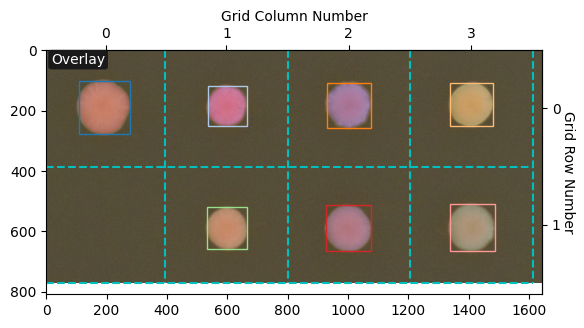

In [3]:
result, count = detect_and_count(OtsuDetector())
print(f"OtsuDetector: {count} colonies")
result.show(overlay=True)

## TriangleDetector

Better than Otsu when one peak dominates — e.g., few colonies on a large
plate.

TriangleDetector: 151 colonies


(<Figure size 640x480 with 1 Axes>, <Axes: >)

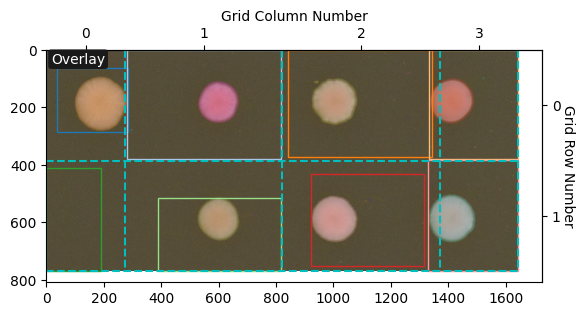

In [4]:
result, count = detect_and_count(TriangleDetector())
print(f"TriangleDetector: {count} colonies")
result.show(overlay=True)

## HysteresisDetector

Uses two thresholds (low and high) to capture colonies with soft edges.
Pixels above `high` are colony; pixels between `low` and `high` are
colony only if connected to a high-confidence pixel.

HysteresisDetector: 7 colonies


(<Figure size 640x480 with 1 Axes>, <Axes: >)

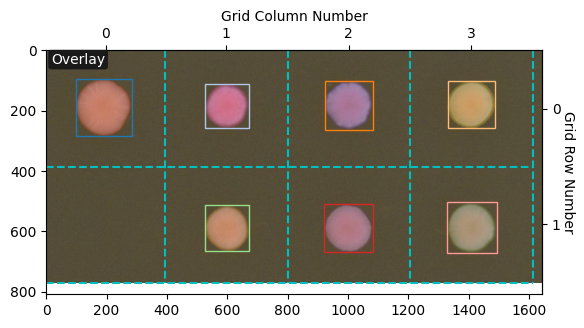

In [5]:
result, count = detect_and_count(HysteresisDetector(low="mean", high="otsu"))
print(f"HysteresisDetector: {count} colonies")
result.show(overlay=True)

## WatershedDetector

Region-growing approach that separates touching colonies. Best for dense
plates where colonies overlap.

WatershedDetector: 7 colonies


(<Figure size 640x480 with 1 Axes>, <Axes: >)

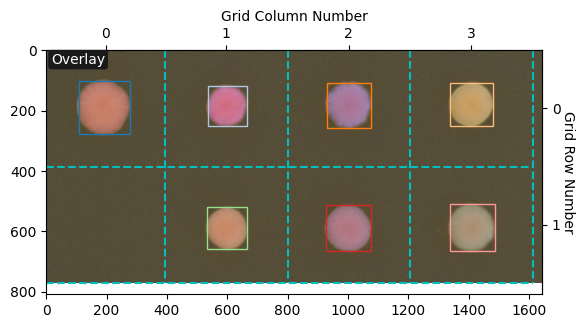

In [6]:
result, count = detect_and_count(WatershedDetector())
print(f"WatershedDetector: {count} colonies")
result.show(overlay=True)

## RoundPeaksDetector

Peak-finding approach optimized for round colonies in grid plates. Fast
and accurate when colonies are circular and well-spaced.

RoundPeaksDetector: 7 colonies


(<Figure size 640x480 with 1 Axes>, <Axes: >)

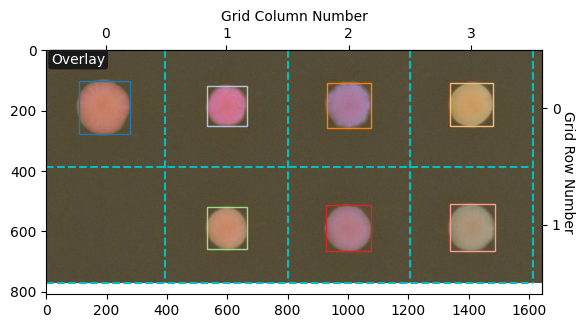

In [7]:
result, count = detect_and_count(RoundPeaksDetector())
print(f"RoundPeaksDetector: {count} colonies")
result.show(overlay=True)

## Comparison Summary

| Detector | Best for | Speed |
|----------|----------|-------|
| `OtsuDetector` | Clean plates, bimodal histograms | Fast |
| `TriangleDetector` | Few colonies on large plates | Fast |
| `HysteresisDetector` | Soft-edged or faint colonies | Fast |
| `WatershedDetector` | Touching/clustered colonies | Moderate |
| `RoundPeaksDetector` | Round colonies in grid plates | Fast |